<a href="https://colab.research.google.com/github/sjensen39/CRiSSP/blob/main/CRiSSP_Sofie_Sanya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CRiSSP: Can AI Taste with Its Eyes?
### Project for CS 171 - Intro to Machine Learning
#### Professor: Tahereh Arabghalizi
#### Project Team: Sofie J and Sanya M

## Step 1 (4/20 - 4/23): EDA

In [55]:
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from dask.diagnostics import ProgressBar
import dask.bag as bag
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

# Make sure to change your file path below
filepath = '/content/drive/MyDrive/food-4/train'
test_filepath = '/content/drive/MyDrive/food-4/test'
os.chdir(filepath)

# computing the amount of images in each class
number_classes = {'Pizza': len(os.listdir('pizza')),
  'Risotto': len(os.listdir('risotto')),
  'Steak': len(os.listdir('steak')),
  'Sushi': len(os.listdir('sushi'))}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


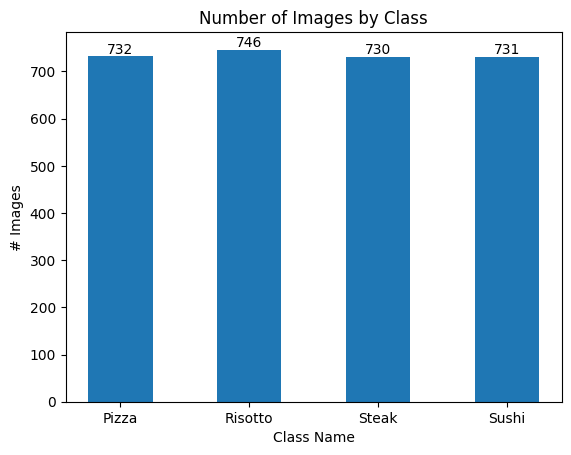

In [56]:
# Plots each total count of images per class with labels on top
categories = number_classes.keys()
counts = number_classes.values()

fig, ax = plt.subplots()
bars = ax.bar(categories, counts, width = 0.5)

# Loop through each bar and place text at the top
for bar in bars:
    y_val = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y_val, int(y_val),
            va='bottom', ha='center')

plt.title("Number of Images by Class");
plt.xlabel('Class Name');
plt.ylabel('# Images');

plt.show()

In [57]:
# dictionary of classes and their directory filepaths
directories = {'Pizza': 'pizza/',
'Risotto': 'risotto/',
'Steak': 'steak/',
'Sushi': 'sushi/'}

# returns the specified image's dimension
def get_dims(file_path):
  with Image.open(file_path) as img:
    height, width = img.size
  return height, width

# saving directory of each class
piz_dir = directories['Pizza']
ris_dir = directories['Risotto']
stk_dir = directories['Steak']
sus_dir = directories['Sushi']

# saving list of images from each class
pizza_files = os.listdir(piz_dir)
risotto_files = os.listdir(ris_dir)
steak_files = os.listdir(stk_dir)
sushi_files = os.listdir(sus_dir)

# Toggle this on for a sample of pizza image dimensions (height, width)

# prints the first 4 image dimensions from the pizza train directory
# print('Sample of pizza image dimensions (height, width)')
# j = 0
# while(j <= 3):
#   print('Pizza Image ', (j+1), ': ', get_dims(os.path.join(piz_dir, pizza_files[j])), sep='')
#   j += 1

[########################################] | 100% Completed | 6.04 s


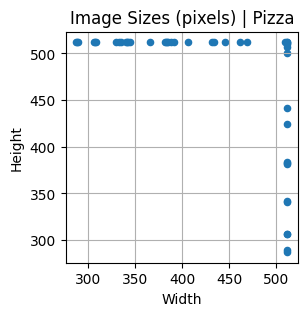

[########################################] | 100% Completed | 5.19 s


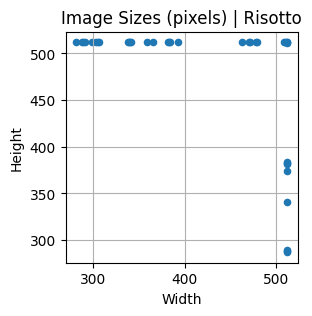

[########################################] | 100% Completed | 5.62 s


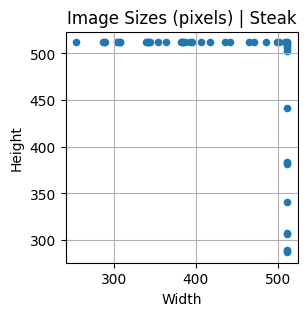

[########################################] | 100% Completed | 5.19 s


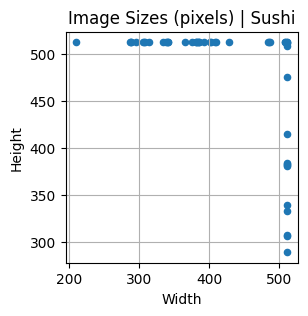

In [58]:
# computes every image dimension using Dask.bag
# collects these into a DataFrame, then finds the unique image dims
# creates a scatterplot of all the unique dims per class
for name,dir in directories.items():
  filepath = dir
  filelist = [filepath + f for f in os.listdir(filepath)]
  dims = bag.from_sequence(filelist).map(get_dims)
  with ProgressBar():
    dims = dims.compute()
    dim_df = pd.DataFrame(dims, columns=['height', 'width'])
    sizes = dim_df.groupby(['height', 'width']).size().reset_index().rename(columns={0:'count'})
  plt.figure(figsize=(3, 3)) # Creates a new figure for each plot
  sizes.plot.scatter(x='width', y='height', ax=plt.gca()); # Pass current axes to plot
  plt.title('Image Sizes (pixels) | {}'.format(name))
  plt.xlabel('Width')
  plt.ylabel('Height')
  plt.grid(True)
  plt.show() # Display the plot for the current class

In [59]:
# Toggle this on to print the count of unique image dimensions for each class

# print('Total count of unique image dimensions by class:')
# for name,dir in directories.items():
#   filepath = dir
#   filelist = [filepath + f for f in os.listdir(filepath)]
#   dims = bag.from_sequence(filelist).map(get_dims)
#   with ProgressBar():
#     dims = dims.compute()
#     dim_df = pd.DataFrame(dims, columns=['height', 'width'])
#     sizes = dim_df.groupby(['height', 'width']).size().reset_index().rename(columns={0:'count'})

#   print(f'\n--- {name} ({len(sizes)} unique dimensions) ---')
#   # Sort by height then width for an ordered list
#   sizes_sorted = sizes.sort_values(by=['height', 'width'])
#   for _, row in sizes_sorted.iterrows():
#     print(f"  {int(row['height'])} x {int(row['width'])}: {int(row['count'])}")

In [60]:
# Shows images (displayed in a 4x4 grid)
nrows = 4
ncols = 4

# Index for iterating over images
pic_index = 0

# first 4 file names of each class directory
# computes the full path name of each sample image
#pizza
next_blight_pix_P = [os.path.join(piz_dir, fname)
                  for fname in pizza_files[pic_index:pic_index+4]]

#risotto
next_blight_pix_R = [os.path.join(ris_dir, fname)
                  for fname in risotto_files[pic_index:pic_index+4]]

#steak
next_blight_pix_St = [os.path.join(stk_dir, fname)
                  for fname in steak_files[pic_index:pic_index+4]]

#sushi
next_blight_pix_Su = [os.path.join(sus_dir, fname)
                  for fname in sushi_files[pic_index:pic_index+4]]

PIZZA


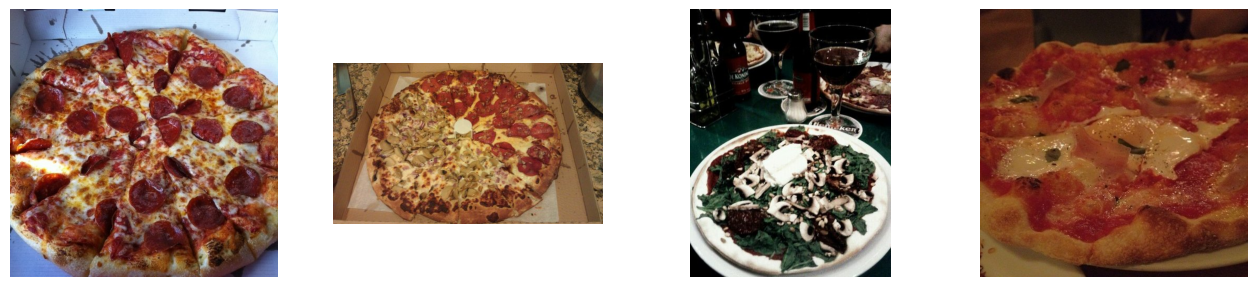


RISOTTO


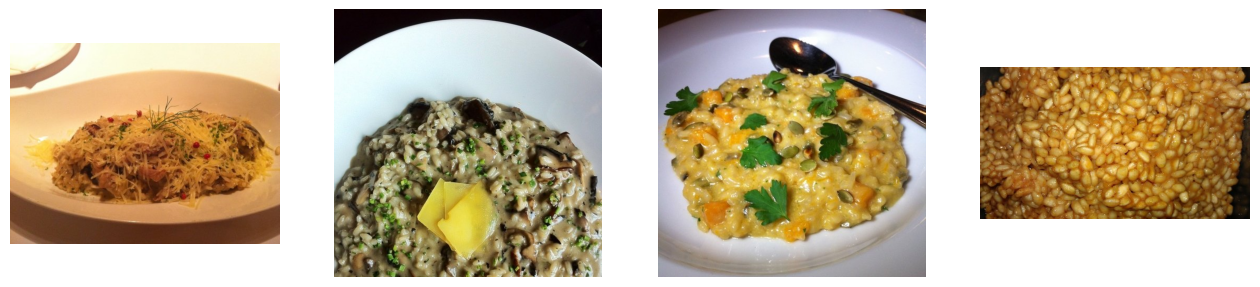


STEAK


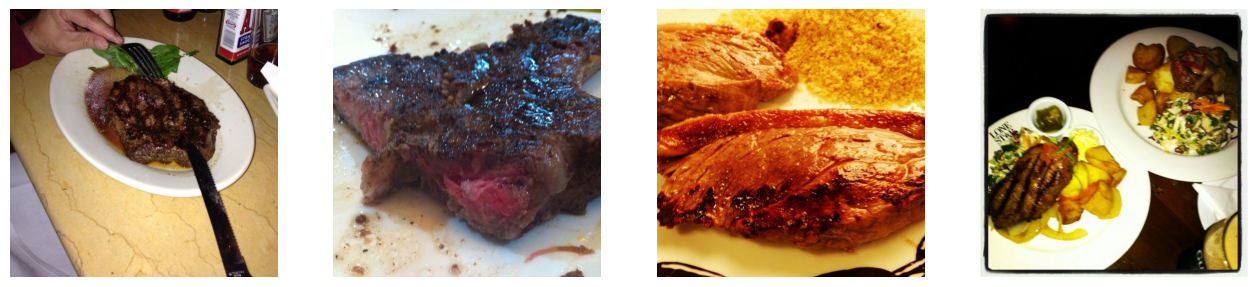


SUSHI


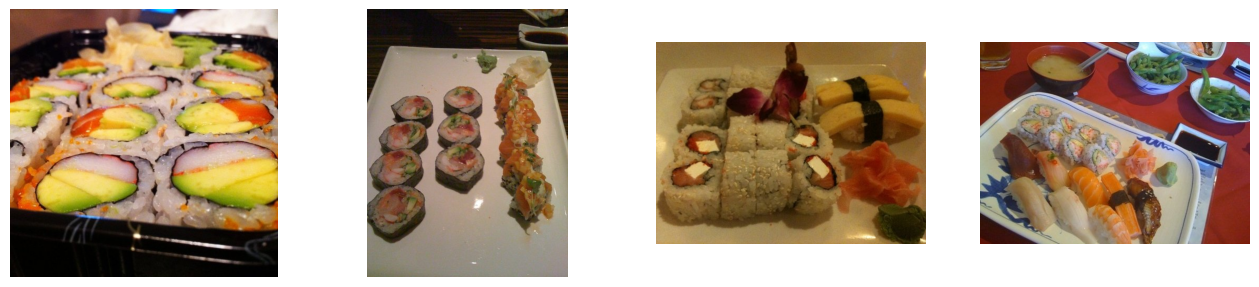

In [61]:
# computes the subplots for creating an 8 image sample for each clas
def show_image_sample(pic_directory):
  fig = plt.gcf()
  fig.set_size_inches(ncols * 4, nrows * 4)
  for i, img_path in enumerate(pic_directory): # iterates through each img
    sp = plt.subplot(nrows, ncols, i + 1)
    sp.axis('Off')
    img = plt.imread(img_path) # reads the image from its path
    plt.imshow(img) # shows current subplot
  plt.show()

print("PIZZA")
show_image_sample(next_blight_pix_P)
print()
print("RISOTTO")
show_image_sample(next_blight_pix_R)
print()
print("STEAK")
show_image_sample(next_blight_pix_St)
print()
print("SUSHI")
show_image_sample(next_blight_pix_Su)

## Step 2 (4/24 - 4/27): Create and train our custom CNN

In [62]:
# When rerunning a training cell or changing parameters that affect a model,
# make sure to rerun all cells starting with this one. To account for reproducibility,
# since the random seed is contained in this cell.
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import random

# Set seeds for reproducibility across all relevant libraries
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# If using CUDA (GPU), set CUDA-specific seeds and determinism options
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Defines our custom CNN architecture
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        # Convolutional Layer 1
        # Input: (batch_size, 3, img height, img width)
        # Output: (batch_size, 32, img height, img width)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        # Max-Pooling Layer 1
        # Output: (batch_size, 32, img_height/2, img_width/2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional Layer 2
        # Input: (batch_size, 32, img_height/2, img_width/2)
        # Output: (batch_size, 64, img_height/2, img_width/2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # Max-Pooling Layer 2
        # Output: (batch_size, 64, img_height/4, img_width/4)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        # The input features for the first fully connected layer depend on the image size after pooling
        # Assuming input images are resized to 64x64 for this custom CNN,
        # after two 2x2 max-pooling layers:
        # Original: 64x64 -> Pool1: 32x32 -> Pool2: 16x16
        # Flattened features: 64 channels * 16 * 16 = 16384
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

        # Softmax layer will be applied in the forward pass using F.softmax

    def forward(self, x):
        # -> conv1 -> ReLU -> pool1
        x = self.pool1(F.relu(self.conv1(x)))
        # -> conv2 -> ReLU -> pool2
        x = self.pool2(F.relu(self.conv2(x)))

        # Flattens the output for the fully connected layers
        # The .view() method reshapes the tensor.
        # -1 infers the batch size.
        x = x.view(-1, 64 * 16 * 16) # Adjust the second argument based on actual image size and layers

        # -> fc1 -> ReLU
        x = F.relu(self.fc1(x))
        # -> fc2
        x = self.fc2(x)

        # Apply softmax to get probabilities. dim=1 means softmax is applied across the class dimension.
        return F.softmax(x, dim=1)

# Determine device and move model to it
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


# Instantiate the model.
num_classes_custom_cnn = 4 # hardcoded
custom_cnn_model = CustomCNN(num_classes_custom_cnn)
custom_cnn_model = custom_cnn_model.to(device)

# Print the model architecture
print(custom_cnn_model)

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [63]:
filepath = '/content/drive/MyDrive/food-4/train' # Reset filepath to the correct training data root
# # Define transformations for the CustomCNN (resize to 64x64, convert to tensor, normalize)
model_transform = transforms.Compose([
    transforms.Resize((64, 64)), # Resize images to 64x64 as expected by CustomCNN
    transforms.ToTensor(),       # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

# # Create datasets using ImageFolder and the custom transformations
full_train_dataset = datasets.ImageFolder(filepath, transform=model_transform)

In [64]:
from collections import defaultdict

# Group image paths by class label
class_to_paths = defaultdict(list)
for path, label_idx in full_train_dataset.samples:
    class_to_paths[label_idx].append(path)

# Determine the target number of samples per class
target_samples_per_class = 730

selected_samples = []
# Randomly select images for each class
for label_idx, paths in class_to_paths.items():
    if len(paths) >= target_samples_per_class:
        selected_paths = random.sample(paths, target_samples_per_class)
    else:
        # If a class has fewer than target_samples_per_class, use all its samples
        print(f"Warning: Class {full_train_dataset.classes[label_idx]} has only {len(paths)} samples, using all of them.")
        selected_paths = paths

    for path in selected_paths:
        selected_samples.append((path, label_idx))

# Define a custom Dataset class that uses the pre-selected samples
class CustomImageFolderDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.classes = full_train_dataset.classes # Inherit classes from original dataset
        self.class_to_idx = full_train_dataset.class_to_idx # Inherit class_to_idx

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Create the balanced training dataset
balanced_train_dataset = CustomImageFolderDataset(selected_samples, transform=model_transform)

new_train_size = int(0.8 * len(balanced_train_dataset)) # 80% for new training set
new_val_size = len(balanced_train_dataset) - new_train_size # Remaining 20% for new validation set

# Use the model_transform for both as it includes resizing to 64x64
new_train_dataset, new_val_dataset = torch.utils.data.random_split(
    balanced_train_dataset, [new_train_size, new_val_size]
)

# Create new data loaders for the balanced datasets
train_loader = DataLoader(new_train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(new_val_dataset, batch_size=32, shuffle=False)

print(f"Original full training samples: {len(full_train_dataset)}")
print(f"Selected balanced training samples: {len(balanced_train_dataset)}")
print(f"New training samples: {len(new_train_dataset)}")
print(f"New validation samples: {len(new_val_dataset)}")
print(f"Number of batches per epoch for new training: {len(train_loader)}")
print(f"Number of batches per epoch for new validation: {len(val_loader)}")

Original full training samples: 2939
Selected balanced training samples: 2920
New training samples: 2336
New validation samples: 584
Number of batches per epoch for new training: 73
Number of batches per epoch for new validation: 19


In [65]:
# Define Loss Function and Optimizer for CustomCNN
criterion_cnn = nn.CrossEntropyLoss() # Suitable for multi-class classification
optimizer_cnn = torch.optim.Adam(custom_cnn_model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

In [66]:
# Training Loop for CustomCNN
num_epochs_cnn = 12 # based on the validation and traning loss and accuracy plots

# Initialize lists to store metrics
train_losses_cnn = []
train_accuracies_cnn = []
val_losses_cnn = []
val_accuracies_cnn = []

print(f"Starting training for CustomCNN on {device}...")

for epoch in range(num_epochs_cnn):
    custom_cnn_model.train() # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer_cnn.zero_grad()

        # Forward pass
        outputs = custom_cnn_model(inputs)
        loss = criterion_cnn(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer_cnn.step()

        # Accumulate batch loss
        running_loss += loss.item() * inputs.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_samples
    epoch_train_accuracy = correct_predictions / total_samples
    train_losses_cnn.append(epoch_train_loss)
    train_accuracies_cnn.append(epoch_train_accuracy)

    # Validation step
    custom_cnn_model.eval() # Set the model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0
    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = custom_cnn_model(inputs)
            loss = criterion_cnn(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total_samples += labels.size(0)
            val_correct_predictions += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total_samples
    epoch_val_accuracy = val_correct_predictions / val_total_samples
    val_losses_cnn.append(epoch_val_loss)
    val_accuracies_cnn.append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs_cnn}, Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_val_accuracy:.4f}")

print("Training of CustomCNN complete!")

# Note:
# when rerunning this cell, make sure to rerun everything starting at the step 2 cell
# (aka the entire "Step 2" section)

Starting training for CustomCNN on cpu...
Epoch 1/12, Train Loss: 1.2880, Train Accuracy: 0.4319, Val Loss: 1.1773, Val Accuracy: 0.5514
Epoch 2/12, Train Loss: 1.1792, Train Accuracy: 0.5484, Val Loss: 1.1494, Val Accuracy: 0.5788
Epoch 3/12, Train Loss: 1.1059, Train Accuracy: 0.6259, Val Loss: 1.1405, Val Accuracy: 0.5976
Epoch 4/12, Train Loss: 1.0529, Train Accuracy: 0.6879, Val Loss: 1.1555, Val Accuracy: 0.5771
Epoch 5/12, Train Loss: 1.0480, Train Accuracy: 0.6909, Val Loss: 1.1314, Val Accuracy: 0.5942
Epoch 6/12, Train Loss: 0.9806, Train Accuracy: 0.7654, Val Loss: 1.0816, Val Accuracy: 0.6610
Epoch 7/12, Train Loss: 0.9462, Train Accuracy: 0.8001, Val Loss: 1.0930, Val Accuracy: 0.6387
Epoch 8/12, Train Loss: 0.9228, Train Accuracy: 0.8271, Val Loss: 1.1097, Val Accuracy: 0.6216
Epoch 9/12, Train Loss: 0.8982, Train Accuracy: 0.8510, Val Loss: 1.1015, Val Accuracy: 0.6267
Epoch 10/12, Train Loss: 0.8899, Train Accuracy: 0.8562, Val Loss: 1.1128, Val Accuracy: 0.6199
Epoch 1

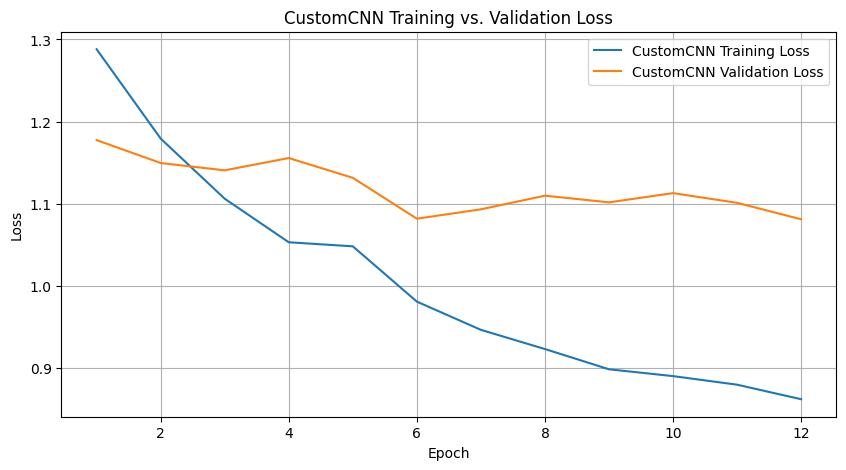

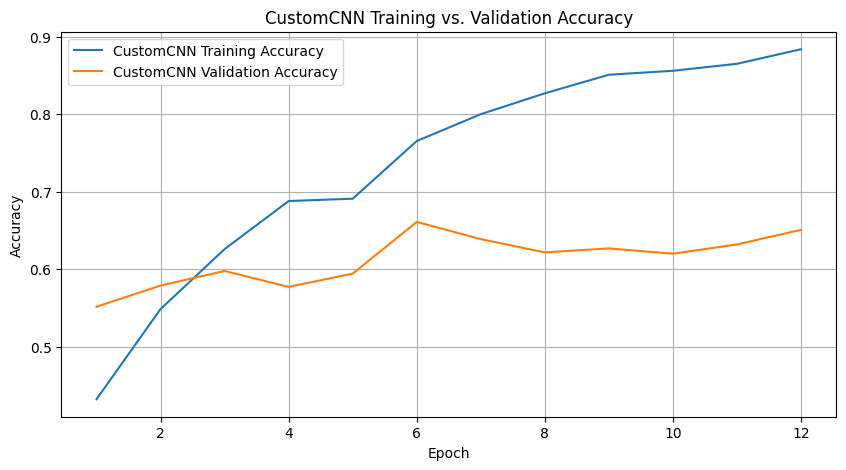

In [67]:
# Plot CustomCNN Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses_cnn) + 1), train_losses_cnn, label='CustomCNN Training Loss')
plt.plot(range(1, len(val_losses_cnn) + 1), val_losses_cnn, label='CustomCNN Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CustomCNN Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot CustomCNN Training and Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_accuracies_cnn) + 1), train_accuracies_cnn, label='CustomCNN Training Accuracy')
plt.plot(range(1, len(val_accuracies_cnn) + 1), val_accuracies_cnn, label='CustomCNN Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CustomCNN Training vs. Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Step 3 (4/28 - 5/3): Use ResNet50 on our dataset

In [68]:
import torchvision.models as models
from torchvision.models import ResNet50_Weights
import torch.nn as nn # Make sure nn is imported for nn.Dropout and nn.Sequential

resnet_model = models.resnet50(weights=ResNet50_Weights.DEFAULT)

for param in resnet_model.parameters():
    param.requires_grad = False

# Add a Dropout layer before the final classification layer
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.5), # Add dropout with a probability of 0.5
    nn.Linear(resnet_model.fc.in_features, 4)
)
resnet_model = resnet_model.to(device)

In [69]:
from torch.optim import lr_scheduler

resnet_num_epochs = 14 # based on the validation and training loss and accuracy plots

criterion_resnet = nn.CrossEntropyLoss()

# Define the optimizer for ResNet50
optimizer_resnet = torch.optim.Adam(resnet_model.fc.parameters(), lr=0.001)

# Define a learning rate scheduler
# This scheduler will decrease the learning rate by a factor of 0.1 every 5 epochs
scheduler = lr_scheduler.StepLR(optimizer_resnet, step_size=5, gamma=0.1)

# Initialize lists to store metrics for ResNet50
train_losses_resnet = []
train_accuracies_resnet = []
val_losses_resnet = []
val_accuracies_resnet = []

print(f"Starting training for ResNet50 on {device}...")

for epoch in range(resnet_num_epochs):
    resnet_model.train() # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet_model(images)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item() * images.size(0)

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_samples
    epoch_train_accuracy = correct_predictions / total_samples
    train_losses_resnet.append(epoch_train_loss)
    train_accuracies_resnet.append(epoch_train_accuracy)

    # Validation step for ResNet50
    resnet_model.eval() # Set the model to evaluation mode
    val_running_loss_resnet = 0.0
    val_correct_predictions_resnet = 0
    val_total_samples_resnet = 0
    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet_model(inputs)
            loss = criterion_resnet(outputs, labels)

            val_running_loss_resnet += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total_samples_resnet += labels.size(0)
            val_correct_predictions_resnet += (predicted == labels).sum().item()

    epoch_val_loss_resnet = val_running_loss_resnet / val_total_samples_resnet
    epoch_val_accuracy_resnet = val_correct_predictions_resnet / val_total_samples_resnet
    val_losses_resnet.append(epoch_val_loss_resnet)
    val_accuracies_resnet.append(epoch_val_accuracy_resnet)

    # Step the scheduler after each epoch
    scheduler.step()

    print(f"Epoch [{epoch+1}/{resnet_num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss_resnet:.4f}, Val Accuracy: {epoch_val_accuracy_resnet:.4f}")

print("Training of ResNet50 complete!")

Starting training for ResNet50 on cpu...
Epoch [1/14], Train Loss: 1.1435, Train Accuracy: 0.5111, Val Loss: 0.9807, Val Accuracy: 0.6678
Epoch [2/14], Train Loss: 0.9090, Train Accuracy: 0.6759, Val Loss: 0.8577, Val Accuracy: 0.7021
Epoch [3/14], Train Loss: 0.8093, Train Accuracy: 0.7106, Val Loss: 0.8077, Val Accuracy: 0.7312
Epoch [4/14], Train Loss: 0.7471, Train Accuracy: 0.7346, Val Loss: 0.7664, Val Accuracy: 0.7123
Epoch [5/14], Train Loss: 0.7528, Train Accuracy: 0.7282, Val Loss: 0.7558, Val Accuracy: 0.7260
Epoch [6/14], Train Loss: 0.6863, Train Accuracy: 0.7504, Val Loss: 0.7484, Val Accuracy: 0.7243
Epoch [7/14], Train Loss: 0.6971, Train Accuracy: 0.7598, Val Loss: 0.7331, Val Accuracy: 0.7260
Epoch [8/14], Train Loss: 0.6802, Train Accuracy: 0.7637, Val Loss: 0.7367, Val Accuracy: 0.7432
Epoch [9/14], Train Loss: 0.6742, Train Accuracy: 0.7633, Val Loss: 0.7341, Val Accuracy: 0.7329
Epoch [10/14], Train Loss: 0.6863, Train Accuracy: 0.7526, Val Loss: 0.7592, Val Accur

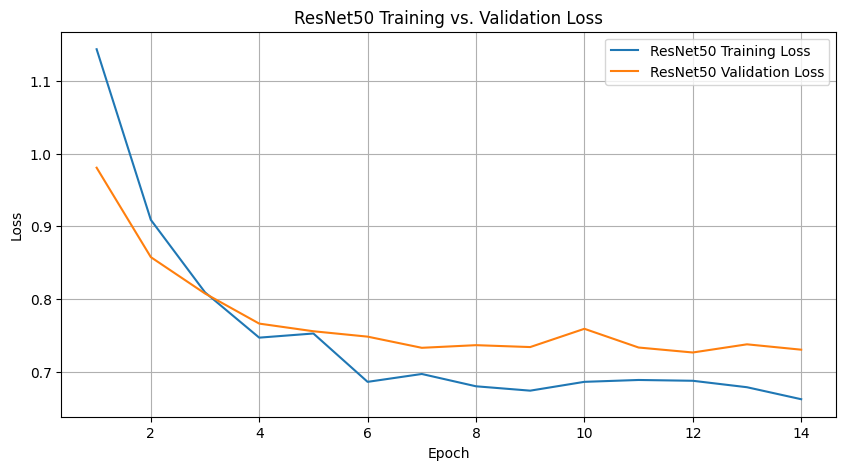

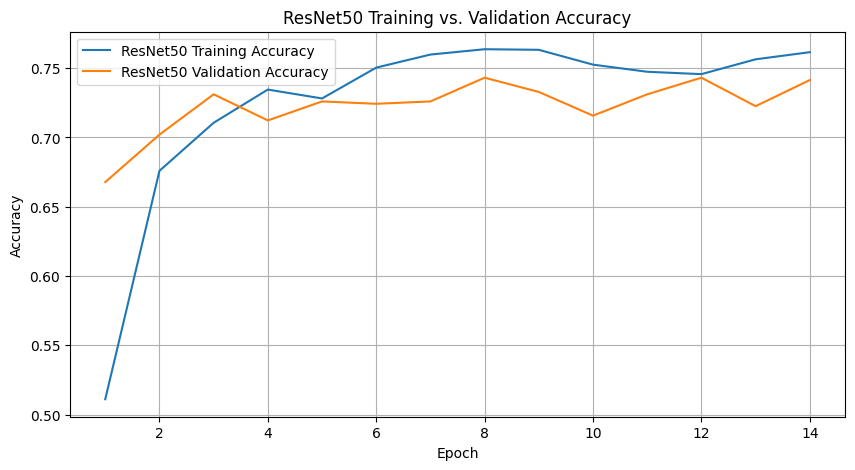

In [70]:
# Plot ResNet50 Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses_resnet) + 1), train_losses_resnet, label='ResNet50 Training Loss')
plt.plot(range(1, len(val_losses_resnet) + 1), val_losses_resnet, label='ResNet50 Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet50 Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot ResNet50 Training and Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_accuracies_resnet) + 1), train_accuracies_resnet, label='ResNet50 Training Accuracy')
plt.plot(range(1, len(val_accuracies_resnet) + 1), val_accuracies_resnet, label='ResNet50 Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet50 Training vs. Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Step 4 (5/4 - 5/7): Model evaluation


In [79]:
from collections import defaultdict

# Ensure test_dataset is available and loaded. If not, we reload it.
test_dataset = datasets.ImageFolder(test_filepath)
if test_filepath not in locals() or test_dataset is None:
    print("Reloading test dataset...")
    test_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    test_dataset = datasets.ImageFolder(test_filepath, transform=test_transform)
    print(f"Test dataset reloaded with {len(test_dataset)} samples.")

# Group image paths by class label for the test dataset
test_class_to_paths = defaultdict(list)
for path, label_idx in test_dataset.samples:
    test_class_to_paths[label_idx].append(path)

# Output the count of images in each test class
print("\nTotal images in each test class:")
for label_idx, paths in test_class_to_paths.items():
    class_name = test_dataset.classes[label_idx]
    print(f"- {class_name}: {len(paths)} images")

Reloading test dataset...
Test dataset reloaded with 987 samples.

Total images in each test class:
- pizza: 243 images
- risotto: 250 images
- steak: 247 images
- sushi: 247 images


In [119]:
import torchvision.transforms as transforms
from torchvision import datasets

# Define the target number of samples per class for the balanced test dataset
target_test_samples_per_class = 240

selected_test_samples = []
# Randomly select images for each test class
for label_idx, paths in test_class_to_paths.items():
    if len(paths) >= target_test_samples_per_class:
        selected_paths = random.sample(paths, target_test_samples_per_class)
    else:
        # If a class has fewer than target_test_samples_per_class, use all its samples
        print(f"Warning: Test class {test_dataset.classes[label_idx]} has only {len(paths)} samples, using all of them.")
        selected_paths = paths

    for path in selected_paths:
        selected_test_samples.append((path, label_idx))

# Create the balanced test dataset using the CustomImageFolderDataset class defined earlier
# We're using the same test_transform (resize to 64x64, convert to tensor, normalize)
balanced_test_dataset = CustomImageFolderDataset(selected_test_samples, transform=test_transform)

# Create a DataLoader for the balanced test dataset
balanced_test_loader = DataLoader(balanced_test_dataset, batch_size=32, shuffle=False)

print(f"Original full test samples: {len(test_dataset)}")
print(f"Selected balanced test samples: {len(balanced_test_dataset)}")
print(f"Number of batches per epoch for balanced test: {len(balanced_test_loader)}")

Original full test samples: 987
Selected balanced test samples: 960
Number of batches per epoch for balanced test: 30


In [120]:
# Evaluation function
def evaluate_model(model, dataloader, device):
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad(): # Disable gradient calculation during inference
        if dataloader is None:
            print("Dataloader is None, cannot evaluate.")
            return 0.0
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

In [121]:
# Evaluate CustomCNN
if balanced_test_loader:
    custom_cnn_accuracy = evaluate_model(custom_cnn_model, balanced_test_loader, device)
    print(f'CustomCNN Test Accuracy: {custom_cnn_accuracy:.2f}%')
else:
    print('CustomCNN test loader not available, skipping evaluation.')

CustomCNN Test Accuracy: 60.52%


In [122]:
# Evaluate ResNet50
if balanced_test_loader:
    resnet_accuracy = evaluate_model(resnet_model, balanced_test_loader, device)
    print(f'ResNet50 Test Accuracy: {resnet_accuracy:.2f}%')
else:
    print('ResNet50 test loader not available, skipping evaluation.')

ResNet50 Test Accuracy: 70.52%


In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# Function to get all predictions and true labels from a model
def get_predictions_and_labels(model, dataloader, device):
    model.eval() # Set model to evaluation mode
    all_labels = []
    all_preds = []
    with torch.no_grad():
        if dataloader is None:
            print("Dataloader is None, cannot get predictions.")
            return [], []
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    return all_labels, all_preds

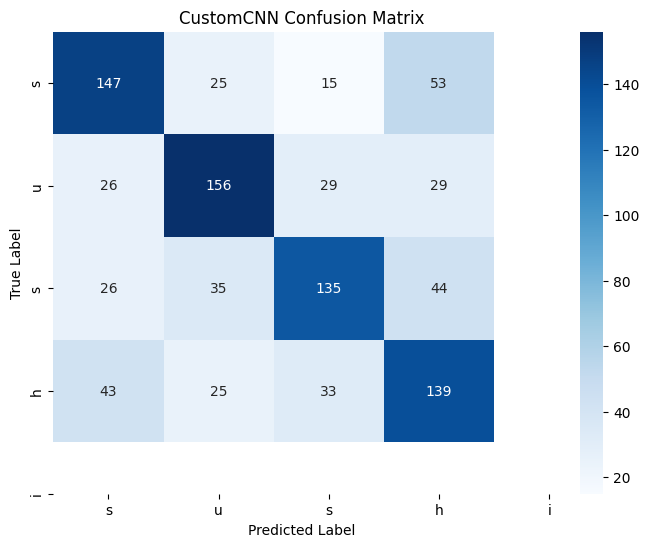

CustomCNN Confusion Matrix displayed.


In [87]:
# Get predictions and true labels for CustomCNN
custom_cnn_true_labels, custom_cnn_predictions = get_predictions_and_labels(custom_cnn_model, balanced_test_loader, device)

# Compute Confusion Matrix for CustomCNN
cm_cnn = confusion_matrix(custom_cnn_true_labels, custom_cnn_predictions)

# Plot Confusion Matrix for CustomCNN
fig_cnn_cm = plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=class_name, yticklabels=class_name)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CustomCNN Confusion Matrix')
plt.show()

print("CustomCNN Confusion Matrix displayed.")

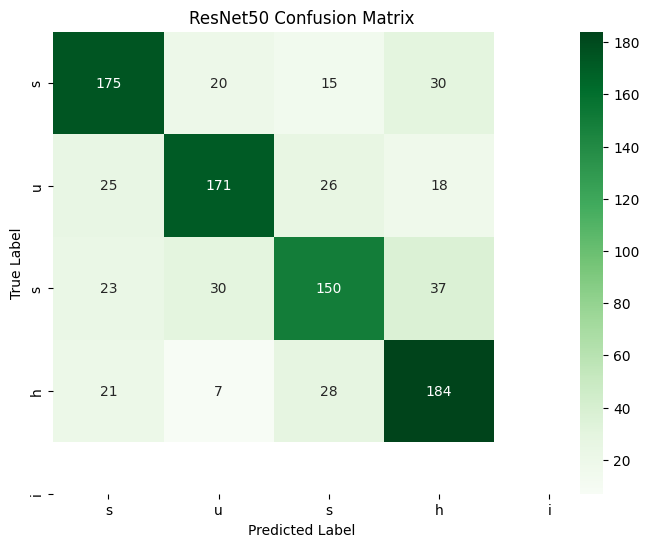

ResNet50 Confusion Matrix displayed.


In [89]:
# Get predictions and true labels for ResNet50
resnet_true_labels, resnet_predictions = get_predictions_and_labels(resnet_model, balanced_test_loader, device)

# Compute Confusion Matrix for ResNet50
cm_resnet = confusion_matrix(resnet_true_labels, resnet_predictions)

# Plot Confusion Matrix for ResNet50
fig_resnet_cm = plt.figure(figsize=(8, 6))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', xticklabels=class_name, yticklabels=class_name)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('ResNet50 Confusion Matrix')
plt.show()

print("ResNet50 Confusion Matrix displayed.")

## Step 5 (5/5 - 5/8): Image Prediction

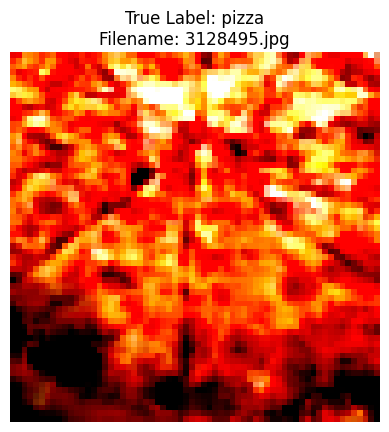

Selected image at index 85 has true label: pizza and filename: 3128495.jpg


In [116]:
# --- Image Selection: Choose ONE of the following methods ---

# Method 1: Specify by image index
# image_index_selection = 290 # Uncomment and set an integer index (e.g., 0 to len(test_dataset)-1)
# image_filename_selection = None # Keep as None if using index selection

# Method 2: Specify by image filename
image_index_selection = None
image_filename_selection = '3128495.jpg' # Uncomment and set a string filename (e.g., '3398309.jpg')

# -----------------------------------------------------------

# Get the class names
class_names = test_dataset.classes

# Determine image_index and image_filename based on selection
if image_index_selection is not None:
    image_index = image_index_selection
    image_filepath = test_dataset.samples[image_index][0]
    image_filename = os.path.basename(image_filepath)
elif image_filename_selection is not None:
    image_filename = image_filename_selection
    found_index = -1
    for i, (path, _) in enumerate(test_dataset.samples):
        if os.path.basename(path) == image_filename:
            found_index = i
            break
    if found_index == -1:
        raise ValueError(f"Filename '{image_filename}' not found in the test dataset.")
    image_index = found_index
    image_filepath = test_dataset.samples[image_index][0]
else:
    raise ValueError("Please specify either 'image_index_selection' or 'image_filename_selection'.")

# Retrieve image and true label from the dataset using the determined index
original_image, true_label_idx = test_dataset[image_index]
true_label_name = class_names[true_label_idx]

# Display the original image and its true label
plt.imshow(original_image.permute(1, 2, 0)) # Permute to (H, W, C) for matplotlib
plt.title(f"True Label: {true_label_name}\nFilename: {image_filename}") # Added filename to title
plt.axis('off')
plt.show()

print(f"Selected image at index {image_index} has true label: {true_label_name} and filename: {image_filename}")

In [117]:
# Preprocess and predict with CustomCNN

# Re-obtain the image to apply transformations directly on the PIL Image (not the tensor)
# This is necessary because test_dataset[index] returns the transformed tensor
# We need the raw image to apply specific transformations again for prediction
raw_image, _ = datasets.ImageFolder(test_filepath)[image_index]

# Apply CustomCNN specific transformations
custom_cnn_input = test_transform(raw_image).unsqueeze(0).to(device) # Add batch dimension and move to device

# Make prediction with CustomCNN
custom_cnn_model.eval() # Set model to evaluation mode
with torch.no_grad():
    custom_cnn_output = custom_cnn_model(custom_cnn_input)
    custom_cnn_probabilities = torch.nn.functional.softmax(custom_cnn_output, dim=1)
    _, custom_cnn_predicted_idx = torch.max(custom_cnn_probabilities, 1)

custom_cnn_predicted_class = class_names[custom_cnn_predicted_idx.item()]
custom_cnn_confidence = custom_cnn_probabilities[0, custom_cnn_predicted_idx.item()].item()

print(f"CustomCNN Prediction: {custom_cnn_predicted_class} (Confidence: {custom_cnn_confidence:.2f})")

CustomCNN Prediction: pizza (Confidence: 0.48)


In [118]:
# Preprocess and predict with ResNet50

# The raw_image is already loaded in the previous cell

# Apply ResNet50 specific transformations
resnet_input = test_transform(raw_image).unsqueeze(0).to(device) # Add batch dimension and move to device

# Make prediction with ResNet50
resnet_model.eval() # Set model to evaluation mode
with torch.no_grad():
    resnet_output = resnet_model(resnet_input)
    resnet_probabilities = torch.nn.functional.softmax(resnet_output, dim=1)
    _, resnet_predicted_idx = torch.max(resnet_probabilities, 1)

# Safely get the predicted index, ensuring it's within bounds
predicted_idx_item = resnet_predicted_idx.item()
if predicted_idx_item < 0 or predicted_idx_item >= len(class_names):
    # If the predicted index is out of range, default to class 0 or handle as unknown
    print(f"Warning: ResNet50 predicted an out-of-range index: {predicted_idx_item}. Defaulting to class 0.")
    predicted_idx_item = 0 # Or you could set it to a special 'unknown' class

resnet_predicted_class = class_names[predicted_idx_item]
resnet_confidence = resnet_probabilities[0, predicted_idx_item].item()

print(f"ResNet50 Prediction: {resnet_predicted_class} (Confidence: {resnet_confidence:.2f})")

ResNet50 Prediction: pizza (Confidence: 0.76)
